In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("IPL_ball_by_ball_updated.csv")
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["total_runs"] = df["runs_off_bat"] + df["extras"]

print("IPL dataset loaded successfully")
print("Shape:", df.shape)
df.head()

IPL dataset loaded successfully
Shape: (243815, 23)


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,total_runs
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [2]:
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Column names:
['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed', 'total_runs']

Data types:
match_id                           int64
season                             int64
start_date                datetime64[ns]
venue                             object
innings                            int64
ball                             float64
batting_team                      object
bowling_team                      object
striker                           object
non_striker                       object
bowler                            object
runs_off_bat                       int64
extras                             int64
wides                            float64
noballs                          float64
byes                             float64
legbyes     

In [3]:
print("Statistical summary:")
df[["season","innings","ball","runs_off_bat","extras","total_runs"]].describe().round(2)

Statistical summary:


,season,innings,ball,runs_off_bat,extras,total_runs
count,243815.00,243815.00,243815.00,243815.00,243815.00,243815.00
mean,2015.61,1.48,9.56,1.25,0.07,1.32
std,4.65,0.50,5.69,1.63,0.34,1.61
min,2008.00,1.00,0.10,0.00,0.00,0.00
25%,2012.00,1.00,4.50,0.00,0.00,0.00
50%,2015.00,1.00,9.40,1.00,0.00,1.00
75%,2020.00,2.00,14.40,1.00,0.00,1.00
max,2023.00,6.00,19.90,6.00,7.00,7.00


In [4]:
filtered = df[(df["season"] >= 2020) & (df["total_runs"] >= 6)]
print("Six-or-more run deliveries from 2020 onward:")
print(filtered[["season","batting_team","striker","runs_off_bat","extras","total_runs"]].head(10).to_string(index=False))

Six-or-more run deliveries from 2020 onward:
 season        batting_team    striker  runs_off_bat  extras  total_runs
   2020      Mumbai Indians  SS Tiwary             6       0           6
   2020      Mumbai Indians  HH Pandya             6       0           6
   2020      Mumbai Indians  HH Pandya             6       0           6
   2020      Mumbai Indians KA Pollard             6       0           6
   2020 Chennai Super Kings  AT Rayudu             6       0           6
   2020 Chennai Super Kings  AT Rayudu             6       0           6
   2020 Chennai Super Kings  AT Rayudu             6       0           6
   2020 Chennai Super Kings  SM Curran             6       0           6
   2020 Chennai Super Kings  SM Curran             6       0           6
   2020      Delhi Capitals    SS Iyer             6       0           6


In [5]:
print("Top batting teams by total runs:")
df.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False).head(10)

Top batting teams by total runs:


batting_team
Mumbai Indians                 39607
Royal Challengers Bangalore    37692
Kolkata Knight Riders          36664
Chennai Super Kings            36105
Rajasthan Royals               32100
Kings XI Punjab                30064
Sunrisers Hyderabad            26019
Delhi Daredevils               24296
Delhi Capitals                 12327
Deccan Chargers                11463
Name: total_runs, dtype: int64

In [6]:
print("Season-wise total runs:")
df.groupby("season")["total_runs"].sum().tail(10)

Season-wise total runs:


season
2014    18931
2015    18353
2016    18862
2017    18786
2018    19901
2019    19434
2020    19416
2021    18637
2022    24395
2023    25688
Name: total_runs, dtype: int64

In [7]:
print("Correlation matrix:")
df[["season","innings","ball","runs_off_bat","extras","total_runs"]].corr().round(2)

Correlation matrix:


,season,innings,ball,runs_off_bat,extras,total_runs
season,1.00,0.00,0.01,0.03,-0.01,0.03
innings,0.00,1.00,-0.05,-0.01,-0.00,-0.01
ball,0.01,-0.05,1.00,0.08,0.00,0.08
runs_off_bat,0.03,-0.01,0.08,1.00,-0.14,0.98
extras,-0.01,-0.00,0.00,-0.14,1.00,0.07
total_runs,0.03,-0.01,0.08,0.98,0.07,1.00


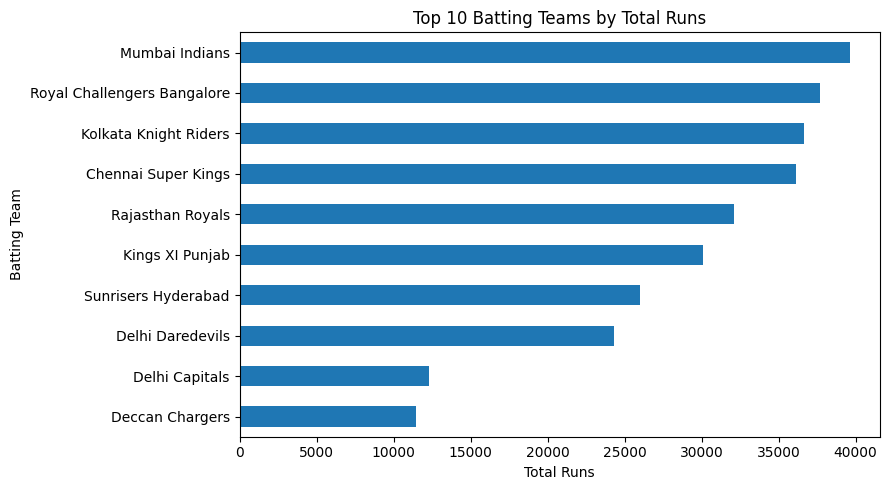

In [8]:
plt.figure(figsize=(9,5))
df.groupby("batting_team")["total_runs"].sum().nlargest(10).sort_values().plot(kind="barh")
plt.title("Top 10 Batting Teams by Total Runs")
plt.xlabel("Total Runs"); plt.ylabel("Batting Team")
plt.tight_layout()
plt.show()

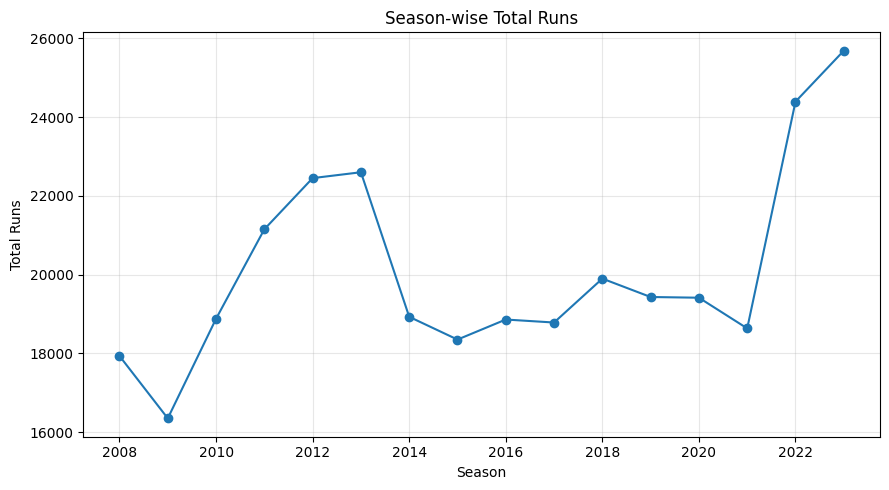

In [9]:
season_runs = df.groupby("season")["total_runs"].sum()
plt.figure(figsize=(9,5))
plt.plot(season_runs.index, season_runs.values, marker="o")
plt.title("Season-wise Total Runs")
plt.xlabel("Season"); plt.ylabel("Total Runs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()